# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

MY CHANGES:
- A possible Who might be: Organizations that focus on boasting education in the US through heavy funding.

- A possible What (what action I want them to take): To consider funding and supporting education in poor states. 

- A possible How: A slide deck with graphs that shows that there's a connection between  the high teacher:student ratio and the low state income.

# 3. Homework - work with your own data

In [1]:
! pip install -qq pandas
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:
df= pd.read_csv("state.csv", sep=",")

In [3]:
df.head()

,year,stabbr,state_name,statefip,region4,region9,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,...,inc_gap130_ratio,coverage,state_chartershare,inc_pubsch,inc_nonpubsch,pubprv_incratio,case,citation,ruling,casetype
0,2022,AL,Alabama,1,South,East South Central,0.036929,0.039076,1108.649,1668.692,...,0.187758,0.825960,0.004447,94260.31,130562.7,0.721955,NaN,NaN,NaN,NaN
1,2022,AK,Alaska,2,West,Pacific,0.043423,0.056036,1776.774,3541.949,...,0.225224,0.821983,0.064936,109327.70,109224.8,1.000942,NaN,NaN,NaN,NaN
2,2022,AZ,Arizona,4,West,Mountain,0.024628,0.026759,1067.853,1859.725,...,0.190693,0.881690,0.351399,118109.90,137257.1,0.860501,NaN,NaN,NaN,NaN
3,2022,AR,Arkansas,5,South,West South Central,0.038394,0.037691,1381.248,2004.317,...,0.206366,0.859202,0.097590,90338.76,102996.4,0.877106,NaN,NaN,NaN,NaN
4,2022,CA,California,6,West,Pacific,0.030721,0.036699,1214.363,2042.963,...,0.155518,0.882351,0.153031,141409.50,225058.4,0.628324,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Columns: 124 entries, year to casetype
dtypes: float64(114), int64(2), str(8)
memory usage: 1.4 MB


In [5]:
df.describe()

,year,statefip,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,predicted_fedrevpp20_,predicted_fedrevpp30_,fairness_fedrevpp,predicted_strevpp0_,...,ftotinc_over185pov,ftotinc_under130pov,ftotinc_over130pov,inc_gap185_ratio,inc_gap130_ratio,coverage,state_chartershare,inc_pubsch,inc_nonpubsch,pubprv_incratio
count,1530.000000,1530.000000,862.000000,1219.000000,1469.000000,1469.000000,1469.000000,1469.000000,1469.000000,1469.000000,...,1173.000000,1173.000000,1173.000000,1173.000000,1173.000000,1173.000000,1122.000000,1173.000000,1173.000000,1173.000000
mean,2007.500000,28.960784,0.036511,0.043408,413.420982,692.790212,1206.766303,2189.739187,6.325168,5200.001802,...,109781.244672,18881.741091,99870.214322,0.248388,0.195499,0.870169,0.043592,84184.277587,117335.307451,0.734698
std,8.658271,15.681961,0.006322,0.007135,358.256173,552.528758,968.487414,1962.443580,4.232710,4429.494386,...,27875.971726,3237.280708,26398.185928,0.039025,0.032970,0.034853,0.085533,24617.219172,37960.625473,0.139107
min,1993.000000,1.000000,0.015759,0.025232,53.021740,93.929260,135.745800,196.178800,0.625949,137.849900,...,64123.150000,11489.350000,55660.230000,0.088856,0.056240,0.726157,0.000000,39960.210000,48956.750000,0.252707
25%,2000.000000,16.000000,0.031993,0.038909,194.514800,359.645100,678.812000,1174.416000,3.534862,2812.058000,...,90088.290000,16368.580000,81310.580000,0.229800,0.177963,0.850274,0.000951,66619.660000,93201.330000,0.640813
50%,2007.500000,29.000000,0.036168,0.042800,322.614800,570.995500,973.945200,1645.171000,5.177474,4150.581000,...,105133.500000,18792.110000,94637.270000,0.251981,0.199773,0.875658,0.020631,79034.990000,110297.500000,0.721956
75%,2015.000000,42.000000,0.040870,0.047228,476.445200,798.407200,1338.598000,2461.689000,7.821515,6106.841000,...,125603.800000,21233.220000,114190.600000,0.272399,0.216515,0.893712,0.053254,97191.840000,133216.700000,0.810311
max,2022.000000,56.000000,0.055217,0.073341,4470.387000,8423.760000,15873.290000,29910.780000,49.728310,55763.150000,...,252619.500000,30517.150000,239824.800000,0.402794,0.291931,0.950709,0.766227,202162.300000,372437.900000,1.393209


In [6]:
df.duplicated().any() #this line shows no duplicated raws

np.False_

In [7]:
df.isnull() 

,year,stabbr,state_name,statefip,region4,region9,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,...,inc_gap130_ratio,coverage,state_chartershare,inc_pubsch,inc_nonpubsch,pubprv_incratio,case,citation,ruling,casetype
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1525,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,True,True,True,True,True
1526,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,True,True,True,True,True
1527,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,True,True,True,True,True
1528,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,True,True,True,True,True


In [8]:
df.isnull().sum()

year                  0
stabbr                0
state_name            0
statefip              0
region4               0
                   ... 
pubprv_incratio     357
case               1474
citation           1475
ruling             1474
casetype           1474
Length: 124, dtype: int64

this shows that some states do not have filed cases against their schools. And since this is irrelevant to what we are looking for, we can remove these columns.


In [9]:
summary = pd.DataFrame({
    "mean": df.mean(numeric_only=True),
    "median": df.median(numeric_only=True),
    "mode": df.mode(numeric_only=True).iloc[0]
})

summary


,mean,median,mode
year,2007.500000,2007.500000,1993.000000
statefip,28.960784,29.000000,1.000000
effort,0.036511,0.036168,0.015759
inc_effort,0.043408,0.042800,0.048040
predicted_fedrevpp0_,413.420982,322.614800,53.021740
...,...,...,...
coverage,0.870169,0.875658,0.878229
state_chartershare,0.043592,0.020631,0.000000
inc_pubsch,84184.277587,79034.990000,39960.210000
inc_nonpubsch,117335.307451,110297.500000,48956.750000


In [10]:
df=df.drop(columns=['case','citation','ruling','casetype'])

In [11]:
states= df['stabbr']
states.nunique()

51

number of states seems to be right.
In general this dataset seems to be very coherent.

In [12]:
one_hot=pd.get_dummies(df['stabbr'])
df=df.join(one_hot)
df.iloc[0:5]

,year,stabbr,state_name,statefip,region4,region9,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
0,2022,AL,Alabama,1,South,East South Central,0.036929,0.039076,1108.649,1668.692,...,False,False,False,False,False,False,False,False,False,False
1,2022,AK,Alaska,2,West,Pacific,0.043423,0.056036,1776.774,3541.949,...,False,False,False,False,False,False,False,False,False,False
2,2022,AZ,Arizona,4,West,Mountain,0.024628,0.026759,1067.853,1859.725,...,False,False,False,False,False,False,False,False,False,False
3,2022,AR,Arkansas,5,South,West South Central,0.038394,0.037691,1381.248,2004.317,...,False,False,False,False,False,False,False,False,False,False
4,2022,CA,California,6,West,Pacific,0.030721,0.036699,1214.363,2042.963,...,False,False,False,False,False,False,False,False,False,False


This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

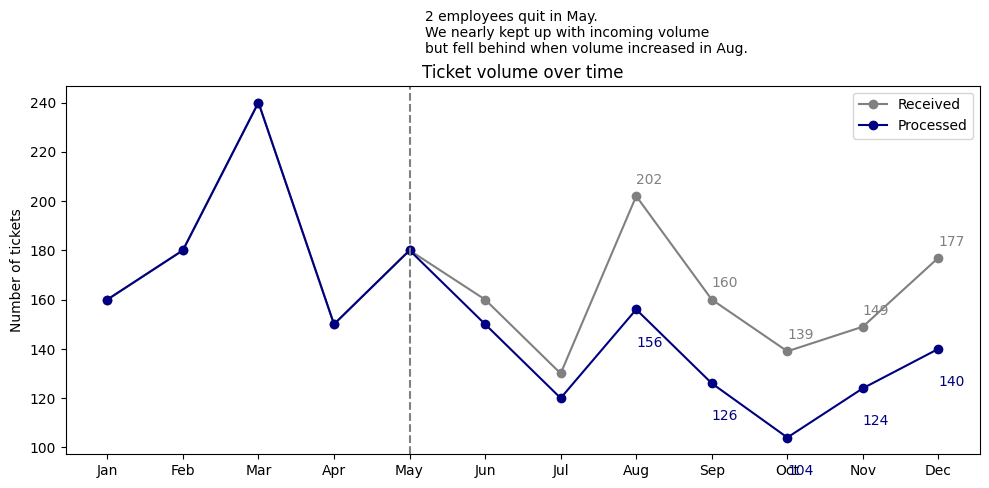

In [14]:
! pip install -qq matplotlib
import matplotlib.pyplot as plt


months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

received = [160,180,240,150,180,160,130,202,160,139,149,177]
processed = [160,180,240,150,180,150,120,156,126,104,124,140]

x = np.arange(len(months))

plt.figure(figsize=(10,5))

# lines
plt.plot(x, received, marker='o', color='gray', label='Received')
plt.plot(x, processed, marker='o', color='navy', label='Processed')

# vertical line for May
plt.axvline(x=4, color='gray', linestyle='--')

# annotation text
plt.text(4.2,260,
         "2 employees quit in May.\n"
         "We nearly kept up with incoming volume\n"
         "but fell behind when volume increased in Aug.",
         fontsize=10)

# labels on last months
for i in range(7,12):
    plt.text(x[i], received[i]+5, str(received[i]), color='gray')
    plt.text(x[i], processed[i]-15, str(processed[i]), color='navy')

plt.xticks(x, months)
plt.ylabel("Number of tickets")
plt.title("Ticket volume over time")

plt.legend()
plt.tight_layout()
plt.show()
